In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

In [2]:
x, y = make_classification(n_features=5, n_informative=5, n_redundant=0, n_clusters_per_class=1, random_state=42)

In [3]:
df = pd.DataFrame(x, columns=[f'feature_{i}' for i in range(x.shape[1])])
df['target'] = y

In [4]:
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,target
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
1,3.243492,1.666651,3.179016,-0.825861,0.778528,1
2,0.712446,-1.201617,1.528624,-0.422788,-0.376825,0
3,1.388329,1.538995,1.243716,0.740905,-2.081063,1
4,2.394647,-3.576345,0.914217,0.363136,2.110329,0


In [5]:
bag = BaggingClassifier(max_features=2, random_state=42)

In [6]:
x

array([[ 1.05390924e+00, -3.86120847e+00,  1.53096292e+00,
         5.96692237e-01,  1.03028412e+00],
       [ 3.24349157e+00,  1.66665142e+00,  3.17901595e+00,
        -8.25861151e-01,  7.78528409e-01],
       [ 7.12446226e-01, -1.20161729e+00,  1.52862420e+00,
        -4.22787747e-01, -3.76825102e-01],
       [ 1.38832923e+00,  1.53899493e+00,  1.24371626e+00,
         7.40904603e-01, -2.08106305e+00],
       [ 2.39464674e+00, -3.57634543e+00,  9.14216947e-01,
         3.63135999e-01,  2.11032899e+00],
       [ 1.20912437e+00, -2.35083035e+00,  1.95170911e+00,
         7.24567040e-01,  1.06294996e+00],
       [ 1.14111198e+00,  2.04921484e+00,  6.28752753e-01,
         1.42783963e+00,  8.19933366e-01],
       [ 1.31699190e+00, -2.16124834e+00,  1.90998433e+00,
        -1.52015568e-01,  4.82576294e-01],
       [-1.03957972e-01,  6.38866102e-01,  3.93205696e+00,
         1.08043362e+00, -1.72996760e+00],
       [ 1.18613062e+00, -5.40805007e+00,  2.40655411e+00,
        -1.15489788e+00

In [7]:
bag.fit(x, y)

,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,2
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


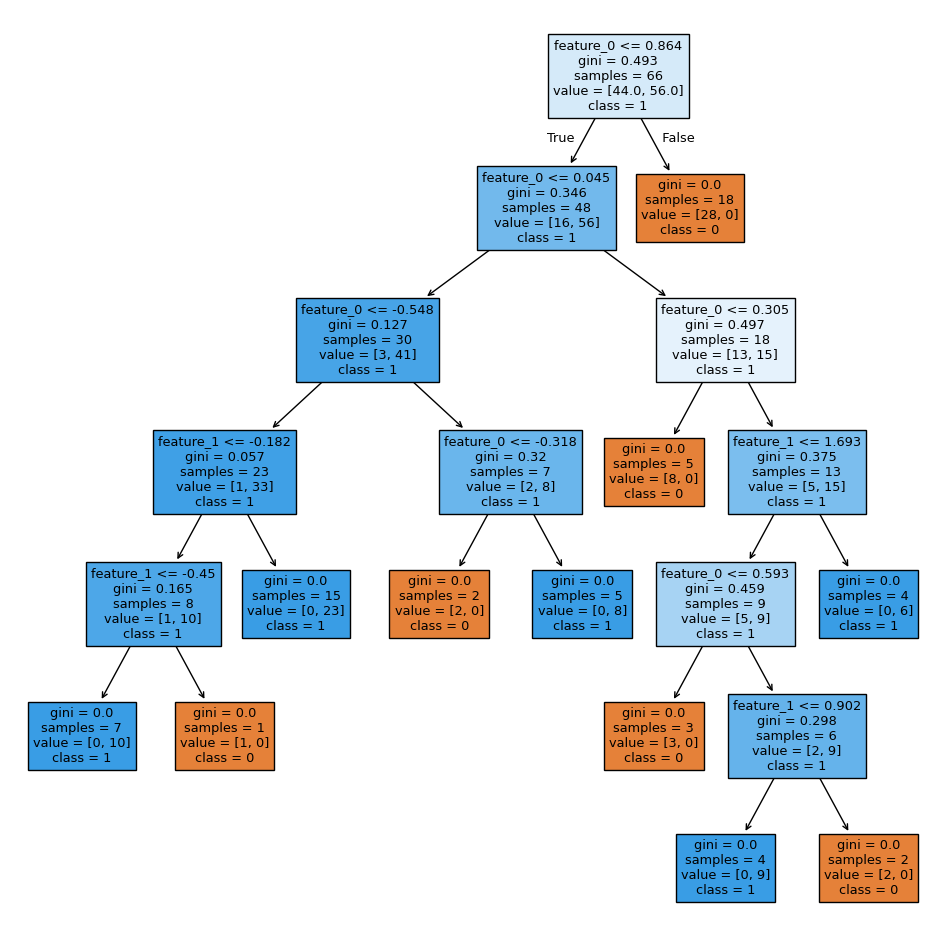

In [8]:
plt.figure(figsize=(12, 12))
plot_tree(bag.estimators_[0], filled=True, feature_names=df.columns[:-1], class_names=['0', '1'])
plt.show()

In [9]:
rf = RandomForestClassifier(max_features=2, random_state=42)
rf.fit(x, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


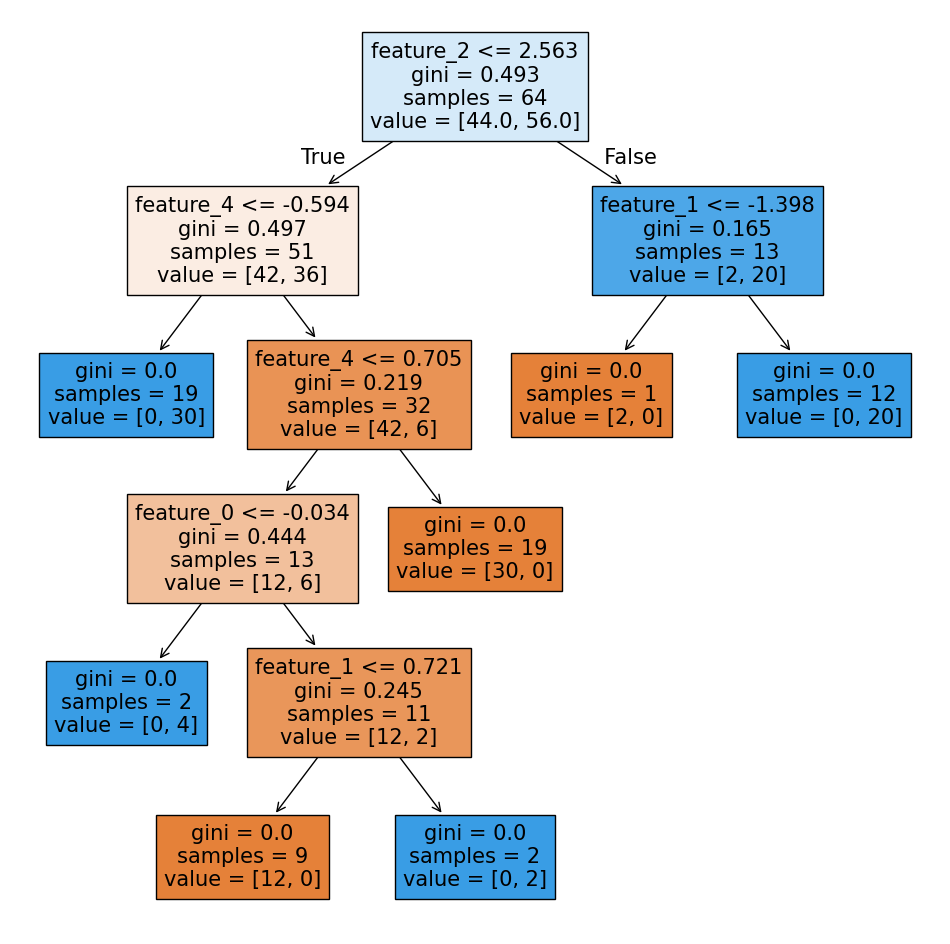

In [11]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[0], feature_names=df.columns[:-1], filled=True)
plt.show()